# Clasificación de Texto con BERT y Hugging Face

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion4/1-text-classification-with-hf.ipynb)

En este notebook implementaremos un clasificador de noticias en español utilizando transformers pero ya basandonos en un modelo pre-entrenado tipo Bidirectional Encoder Representation from Transformers o BERT por sus siglas y disponible en Hugging Face Hub. El propósito de esta tarea es aprender a utilizar modelos pre-entrenados que por si mismos, sería sumamente costoso entrenar desde cero, tanto por el poder de computo como la disponibilidad de datos de entrenamiento. Entonces gran parte de la labor ya ha sido realizada por nosotros. Nuestra tarea ahora es especializar el modelo en la tarea que tenemos a la mano.

En esta ocasión, vamos a apartarnos de Pytorch Lightning y harémos uso extensivo de la herramientas de Hugging Face, las cuales están especialmente desarrolladas para este tipo de tareas, incluyendo la interacción con modelos pre-entrenados.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [BETO: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](http://arxiv.org/abs/1810.04805)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/v4.41.3/en/index)
- [Hugging Face Accelerate](https://huggingface.co/docs/accelerate/index)
- [Hugging Face Evaluate](https://huggingface.co/docs/evaluate/v0.4.0/en/index)
- [Hugging Face Datasets](https://huggingface.co/docs/datasets/v2.19.0/en/index)

In [105]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [106]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets 'transformers[torch]' sentence-transformers torchinfo evaluate

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Fetched 3,917 B in 1s (4,094 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [107]:
# =========================
# CONFIGURACIÓN GLOBAL
# =========================

MODEL_CKPT = "BSC-LT/MrBERT"
MAX_LENGTH = 128
BATCH_SIZE = 8
EPOCHS = 2
LEARNING_RATE = 1e-3#2e-5

### Cargando el dataset
Este es un dataset pequeño de articulos de noticias en idioma español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [108]:
from datasets import load_dataset
import warnings
import os

warnings.filterwarnings("ignore")
dataset = load_dataset('MarcOrfilaCarreras/spanish-news', split='train')
dataset.set_format(type="pandas")
df = dataset.to_pandas()
df.head()

,language,category,newspaper,hash,text
0,es,play,de_lector_a_lector,1bcca6442ad224ca731b6e99b018ac219116e34c,Valladolid misteriosa es el título del nuevo l...
1,es,play,de_lector_a_lector,b387bc0a5ad68524c8aa5da489555ca41d5a3575,"El coraje de ser, de Mónica Cavallé, la aventu..."
2,es,play,de_lector_a_lector,cd4829e6999bb9e5cbb417daf6fd34b4fb8a86dc,"En la Tercera el francés, de Federico Supervie..."
3,es,play,de_lector_a_lector,467ba1276df60fdcfbe997d5f77e6136a028ee92,No fue Un fuego azul la primera novela de Pedr...
4,es,play,de_lector_a_lector,ef1dfb73db89b8ed5d0c66ed0ad03ab1d12a8157,"El tropiezo del tiempo, de Eduardo Álvarez Tuñ..."


In [109]:
import numpy as np

id2category = dict(enumerate(np.unique(df['category'])))
category2id = {v: k for k, v in id2category.items()}

df['category_id'] = df['category'].apply(lambda x: category2id[x])
df = df[['text', 'category', 'category_id']].sample(frac=1).reset_index(drop=True)
df.head()

,text,category,category_id
0,"Las Palmas de Gran Canaria, 15 feb (EFE).- La ...",economy,2
1,Situación equipo:Lo más importante somos nosot...,sport,10
2,Castilla y León ha registró en 2023 una bajada...,economy,2
3,El jengibre fresco se ha convertido en un cond...,alimentation,0
4,Urban Automotive celebra el éxito de su paquet...,motor,6


# Nuevo modelo MrBert

Encontramos un modelo llamativo en Huggingface, con una arquitectura moderna de BERT.

**Ficha del modelo MrBERT**
MrBERT es un modelo codificador fundamental multilingüe basado en la arquitectura ModernBERT. Ha sido preentrenado desde cero con un corpus a gran escala de 6,1 billones de tokens que abarca 35 idiomas europeos, además de código. Gracias al diseño modernizado de estilo BERT de ModernBERT, MrBERT combina representaciones bidireccionales robustas con un modelado eficiente de contexto extenso.

Diseñado como un codificador multilingüe de propósito general, MrBERT es idóneo para una amplia gama de tareas posteriores, como recuperación, clasificación, búsqueda semántica y comprensión interlingüística en diversos idiomas.

**Descripción técnica**
Parámetros del modelo 308M
Tipo de tokenizador SPM
Tamaño del vocabulario 256 000
Precisión bfloat16
Longitud del contexto 8192
Hiperparámetros de entrenamiento

**Valor del hiperparámetro**
Objetivo de preentrenamiento: Modelado de lenguaje enmascarado
Tasa de aprendizaje 1E-03
Planificador de tasa de aprendizaje WSD
Calentamiento 3 000 000 000 tokens
Optimizador decoupled_stableadamw
Hiperparámetros del optimizador: AdamW (β1=0,9, β2=0,98, ε =1e-06)
Decaimiento de peso 1E-05
Tamaño del lote global 4096 (contexto corto) / 512 (contexto largo)
Dropout 1E-01
Función de activación GeLU

###Definición del Tokenizer

Al cambiar el modelo, es necesario utilizar el tokenizador específico con el que fue entrenado, ya que existe una correspondencia directa entre el vocabulario del modelo y la forma en que los textos son convertidos en tokens.

En este caso, se emplea el tokenizador asociado a MrBERT, basado en SentencePiece (SPM), lo que permite una segmentación más flexible del texto en comparación con tokenizadores basados en palabras completas.

Este tipo de tokenización resulta especialmente útil en textos con variabilidad lingüística, ya que permite descomponer palabras desconocidas en subunidades, reduciendo el problema de palabras fuera de vocabulario (OOV).

La correcta alineación entre modelo y tokenizador es crítica, ya que un desajuste puede degradar significativamente el desempeño del modelo.

In [110]:
from transformers import AutoTokenizer

# Cambiamos al modelo optimizado del BSC-LT
#model_ckpt =  "BSC-LT/MrBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

Ahora sometamos a prueba el tokenizador con la misma frase del notebook anterior.

In [111]:
#tokenizer.pad_token = '[PAD]'
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Model max length:", tokenizer.model_max_length)
#tokenizer("hola mundo!!", max_length=10, truncation=True, padding='max_length').tokens()
# Texto de prueba
text = "hola mundo!!"

# Tokenización con parámetros razonables
encoded = tokenizer(
    text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH  # valor de prueba
)

# Visualización completa
print("\nTexto original:", text)
print("Tokens:", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("Longitud:", len(encoded["input_ids"]))
print("Attention mask:", encoded["attention_mask"])

Pad token: <pad>
EOS token: </s>
Model max length: 8192

Texto original: hola mundo!!
Tokens: ['<s>', '▁h', 'ola', '▁mundo', '!!', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad

**Observacion:**

A partir de la configuración del tokenizer, se evidencia que el modelo ya incorpora tokens especiales como `<pad>` y `</s>`, por lo que no es necesario definir manualmente estos valores.

La tokenización muestra que el texto es descompuesto en subunidades, lo que permite al modelo manejar variaciones lingüísticas y palabras desconocidas.

Además, se observa que el modelo soporta secuencias de hasta 8192 tokens, lo cual representa una ventaja frente a modelos tradicionales. Sin embargo, en la práctica, utilizar longitudes tan grandes puede ser ineficiente, por lo que es necesario definir un valor de max_length adecuado basado en el análisis del dataset.

Ahora, observemos su vocabulario.

In [112]:
tokenizer.vocab_size

256000

**Observacion:**

El tokenizador presenta un tamaño de vocabulario de 256,000 tokens, significativamente mayor que el de modelos tradicionales como BERT-base (~30,000 tokens).

Este incremento permite una representación más detallada de subpalabras y símbolos, lo que puede mejorar la capacidad del modelo para capturar matices semánticos y reducir ambigüedades en el lenguaje.

Sin embargo, un vocabulario más grande también implica un mayor consumo de memoria y una mayor complejidad computacional. Por lo tanto, no siempre garantiza una mejora en el rendimiento, especialmente si el dataset no presenta suficiente diversidad léxica.

In [113]:
tokenizer.model_max_length

8192

In [114]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

**Observacion**

El modelo soporta una longitud máxima de 8192 tokens, lo cual representa una ventaja frente a modelos tradicionales que suelen limitarse a 512 tokens. Esto permite procesar textos más largos sin necesidad de truncamiento.

No obstante, utilizar secuencias de esta longitud implica un alto costo computacional, por lo que en la práctica es necesario definir un valor de max_length ajustado al dataset.

Además, se observa que el modelo utiliza como entradas principales input_ids y attention_mask, lo cual es consistente con arquitecturas tipo Transformer, donde la máscara de atención permite diferenciar entre tokens reales y tokens de padding durante el entrenamiento.

## Ajuste en bloqueo de parametros

Ajuste en la forma como se congelan los parametros del modelo, se bloquean primero todos los parametros y luego se desbloquea unicamente el clasificador.


In [115]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

# Usar texto real del dataset (NO ejemplo trivial)
sample_text = df['text'].iloc[0]

inputs = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

print("Input Shapes & Types:")
print({k: (v.shape, v.dtype) for k, v in inputs.items()})

# Cargar modelo
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=len(category2id)
).to(device)

# Congelar backbone (feature extractor)
for param in model.base_model.parameters():
    param.requires_grad = False

# Descongelar clasificador
for param in model.classifier.parameters():
    param.requires_grad = True

Input Shapes & Types:
{'input_ids': (torch.Size([1, 128]), torch.int64), 'attention_mask': (torch.Size([1, 128]), torch.int64)}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: BSC-LT/MrBERT
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Observacion**

se opta por congelar los parámetros del modelo base (backbone) y entrenar únicamente la capa de clasificación. Esta estrategia permite reducir significativamente el costo computacional, ya que solo una pequeña fracción de los parámetros es actualizada durante el entrenamiento.

Sin embargo, esta decisión también implica que el modelo no adapta sus representaciones internas al dataset específico, lo que puede limitar su desempeño en tareas más complejas o con dominio específico.


**Observemos todos los modulos registrados en el modelo:**

In [116]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'model',
 'model.embeddings',
 'model.embeddings.tok_embeddings',
 'model.embeddings.norm',
 'model.embeddings.drop',
 'model.layers',
 'model.layers.0',
 'model.layers.0.attn_norm',
 'model.layers.0.attn',
 'model.layers.0.attn.Wqkv',
 'model.layers.0.attn.Wo',
 'model.layers.0.attn.out_drop',
 'model.layers.0.mlp_norm',
 'model.layers.0.mlp',
 'model.layers.0.mlp.Wi',
 'model.layers.0.mlp.act',
 'model.layers.0.mlp.drop',
 'model.layers.0.mlp.Wo',
 'model.layers.1',
 'model.layers.1.attn_norm',
 'model.layers.1.attn',
 'model.layers.1.attn.Wqkv',
 'model.layers.1.attn.Wo',
 'model.layers.1.attn.out_drop',
 'model.layers.1.mlp_norm',
 'model.layers.1.mlp',
 'model.layers.1.mlp.Wi',
 'model.layers.1.mlp.act',
 'model.layers.1.mlp.drop',
 'model.layers.1.mlp.Wo',
 'model.layers.2',
 'model.layers.2.attn_norm',
 'model.layers.2.attn',
 'model.layers.2.attn.Wqkv',
 'model.layers.2.attn.Wo',
 'model.layers.2.attn.out_drop',
 'model.layers.2.mlp_norm',
 'model.layers.2.mlp',
 'model.l

Observamos que la capa final es efectivamente el clasificador. Ahora hagamos una prueba pasando un dummy input:

In [117]:
with torch.no_grad():
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
print({k: v.shape for k, v in outputs.items()})

{'logits': torch.Size([1, 12])}


In [118]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.3906, -0.0762,  0.7344,  0.4785,  0.4023,  0.4023, -1.0781, -0.1582,
         -0.1797,  1.0312,  0.5273, -0.0742]], device='cuda:0',
       dtype=torch.bfloat16), hidden_states=None, attentions=None)

In [119]:
model.classifier

Linear(in_features=768, out_features=12, bias=True)


Mantenemos la forma como se preparan los datos para el entrenamiento.

Hugging Face Datasets convenientemente implementa una función para hacer el train-test splig en nuestro dataset y automáticamente creará nuevas llaves en el mismo para diferenciarlo.

Dado que el conjunto de validación y prueba cuenta con aproximadamente 1000 ejemplos, se reconoce que la cantidad de muestras por clase es relativamente limitada (~80–90 ejemplos por clase), lo que puede introducir variabilidad en las métricas y afectar la estabilidad de la evaluación.

In [120]:
training_dataset = dataset.train_test_split(train_size=0.8)
validation_dataset = training_dataset['test'].train_test_split(train_size=0.5)

In [121]:
from datasets.dataset_dict import DatasetDict

new_dataset = DatasetDict({
    'train': training_dataset['train'],
    'val': validation_dataset['train'],
    'test': validation_dataset['test'],
})
new_dataset

DatasetDict({
    train: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text'],
        num_rows: 1020
    })
})

In [122]:
from collections import Counter

def show_distribution(ds, name):
    counts = Counter(ds['category'])
    total = sum(counts.values())
    print(f"\n{name}")
    for k, v in counts.items():
        print(f"{k}: {v/total:.2%}")

show_distribution(new_dataset['train'], "TRAIN")
show_distribution(new_dataset['val'], "VAL")
show_distribution(new_dataset['test'], "TEST")


TRAIN
military: 8.25%
tech: 8.43%
alimentation: 8.27%
politics: 8.36%
fashion: 8.27%
medicine: 8.26%
economy: 8.33%
astronomy: 8.30%
religion: 8.49%
play: 8.35%
motor: 8.48%
sport: 8.21%

VAL
astronomy: 9.22%
fashion: 8.14%
economy: 8.43%
tech: 7.65%
military: 7.84%
politics: 8.73%
motor: 8.33%
sport: 9.12%
medicine: 7.94%
religion: 8.33%
alimentation: 7.75%
play: 8.53%

TEST
alimentation: 9.41%
military: 9.51%
fashion: 9.02%
tech: 8.24%
play: 8.04%
astronomy: 7.75%
motor: 7.16%
economy: 8.24%
religion: 7.06%
medicine: 9.31%
sport: 8.53%
politics: 7.75%


Se observa que la distribución de clases en los conjuntos de entrenamiento, validación y prueba se mantiene relativamente balanceada.

Sin embargo, se identifican pequeñas variaciones en el conjunto de validación, donde algunas clases presentan proporciones ligeramente superiores (≈9–10%) en comparación con otras (≈7–8%).

Estas diferencias son esperables debido al tamaño reducido del subconjunto de validación, y no representan un sesgo significativo, aunque podrían influir levemente en la estimación del desempeño durante el ajuste del modelo.

In [123]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True, padding='max_length')
    return _preprocess_function

def tokenize(max_len: int = 8):
    def _tokenize(batch):
        return tokenizer(batch['text'], max_length=max_len, truncation=True, padding='max_length')
    return _tokenize

def category_names_2_ids(batch):
    batch['label'] = category2id[batch['category']]
    return batch


In [124]:
for split in new_dataset.keys():
    new_dataset[split].set_format(type=None)

tokenized_dataset = new_dataset.map(preprocess_function(max_len=512), batched=True)
tokenized_dataset = tokenized_dataset.map(category_names_2_ids)
tokenized_dataset

Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'attention_mask', 'label'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
})

#### Entrenamiento

Ahora procederemos al entrenamiento. Aquí harémos uso de las API de HuggingFace directamente.

In [104]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
        "precision_macro": precision.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall_macro": recall.compute(predictions=preds, references=labels, average="macro")["recall"],
    }

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir='./hf',
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_eval_batch_size=BATCH_SIZE,
    per_device_train_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='tensorboard',
    optim="adamw_torch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

Se incorporaron métricas adicionales como F1-score, precisión y recall, con el fin de evaluar el desempeño del modelo de manera más robusta en un problema multiclase.

Además, se implementó padding dinámico mediante un DataCollator, optimizando el uso de memoria durante el entrenamiento.

Se incluyó early stopping para evitar sobreajuste y mejorar la selección del mejor modelo

Con esto nos basta para ejecutar el entrenamiento:

In [ ]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.193125,1.129642,0.644118,0.645282,0.717684,0.645704


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Comparacion con el modelo original + Fine-tunning**
Con 2 iteraciones para alcanzar un tasa de correctitud approx. 0.959804.

### Resultados del Nuevo modelo

**Observacion**

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir hf/runs

Y ahora evaluemos el modelo en el conjunto de prueba:

Lo comparamos con el modelo original con fine-tunning:

{'eval_loss': 0.17438913881778717,
 'eval_accuracy': 0.9676470588235294,
 'eval_runtime': 4.2697,
 'eval_samples_per_second': 239.828,
 'eval_steps_per_second': 29.978,
 'epoch': 2.0}

In [ ]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

**Observacion**

Modelo Original + Fine-tunning: alcanzado una correctitud superior al $\approx 90\%$ en el conjunto de prueba!

### Haciendo uso del modelo
Ahora, hagamos predicciónes con el modelo y observemos los resultados.

In [98]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
0,No log,3.007292,0.170588,0.140890,0.268587,0.171681


PredictionOutput(predictions=array([[-1.7421875 , -1.515625  , -3.015625  , ..., -0.69140625,
         0.18652344,  1.9453125 ],
       [-2.65625   , -2.28125   , -1.7890625 , ..., -1.890625  ,
        -0.640625  ,  2.234375  ],
       [-1.7421875 , -1.28125   , -3.46875   , ..., -0.73828125,
        -0.38085938,  1.875     ],
       ...,
       [-3.40625   , -3.21875   ,  2.265625  , ..., -2.        ,
        -2.3125    ,  2.234375  ],
       [-1.8671875 , -1.25      , -3.        , ..., -1.296875  ,
         0.74609375,  1.8515625 ],
       [-3.9375    , -2.125     , -0.87109375, ..., -0.83984375,
        -0.6640625 ,  1.3203125 ]], dtype=float32), label_ids=array([0, 5, 3, ..., 7, 0, 8]), metrics={'test_loss': 3.007291555404663, 'test_accuracy': 0.17058823529411765, 'test_f1_macro': 0.14088966981750153, 'test_precision_macro': 0.26858663509396624, 'test_recall_macro': 0.1716814780214375, 'test_runtime': 72.1888, 'test_samples_per_second': 14.13, 'test_steps_per_second': 1.773})

In [99]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2category[label], predicted_labels)))
test_set

Dataset({
    features: ['language', 'category', 'newspaper', 'hash', 'text', 'input_ids', 'attention_mask', 'label', 'prediction_label', 'prediction'],
    num_rows: 1020
})

In [100]:
columns = ['text', 'label', 'prediction_label', 'category', 'prediction']
test_set.set_format('pandas', columns=columns)
df = test_set.to_pandas()[columns]
df.style.set_table_styles(
    [
        {'selector': 'td', 'props': [('word-wrap', 'break-word')]}
    ]
)
df.head(15)

,text,label,prediction_label,category,prediction
0,Está tan extendida hoy en todo el mundo que no...,0,7,alimentation,play
1,Embraer y Fokker Services planean profundizar ...,5,11,military,tech
2,David Beckham repite con H&M y en calzoncillos...,3,6,fashion,motor
3,"Hablar de la 'maison' Dior es hablar de lujo, ...",3,7,fashion,play
4,SDLE ha presentado distintas líneas de product...,5,6,military,motor
5,"IWI (Israel Weapon Industries), referente mu...",5,11,military,tech
6,"La policía metropolitana de Londres (la 'Met',...",11,11,tech,tech
7,Ikea suele adelantar el catálogo de otoño-invi...,0,11,alimentation,tech
8,Algunos dudaban sobre la posibilidad de que 'L...,7,7,play,play
9,La respuesta a la pregunta sobre si podemos sa...,1,11,astronomy,tech


Observemos los errores.

In [101]:
errors = df[df['label'] != df['prediction_label']]
errors.head(15)

,text,label,prediction_label,category,prediction
0,Está tan extendida hoy en todo el mundo que no...,0,7,alimentation,play
1,Embraer y Fokker Services planean profundizar ...,5,11,military,tech
2,David Beckham repite con H&M y en calzoncillos...,3,6,fashion,motor
3,"Hablar de la 'maison' Dior es hablar de lujo, ...",3,7,fashion,play
4,SDLE ha presentado distintas líneas de product...,5,6,military,motor
5,"IWI (Israel Weapon Industries), referente mu...",5,11,military,tech
7,Ikea suele adelantar el catálogo de otoño-invi...,0,11,alimentation,tech
9,La respuesta a la pregunta sobre si podemos sa...,1,11,astronomy,tech
11,"NVIDIA es una empresa que, además de desarroll...",11,7,tech,play
12,Daniel Ricciardo no ha tenido una trayectoria ...,6,11,motor,tech


Hemos alcanzado una correctitud superior al $\approx 90\%$ en el conjunto de prueba!

Con fine tuning, todas las capas del modelo ajustarán sus parámetros en respuesta al proceso de entrenamiento, por lo que es natural que la calidad de los resultados se incremente significativamente. Sin embargo, no hay que abusar del fine tuning ya que tiende a hacer overfitting al conjunto con el que se entrena, por eso también es recomendable no entrenarlo demasiado.

## Explicabilidad con Mapas de Atención

En el siguiente bloque, extraeremos los "pesos de atención" (attention weights) de la última capa del modelo, estos pesos indican qué tokens consideró el modelo más importantes para relacionarlas con el resto de la secuencia.

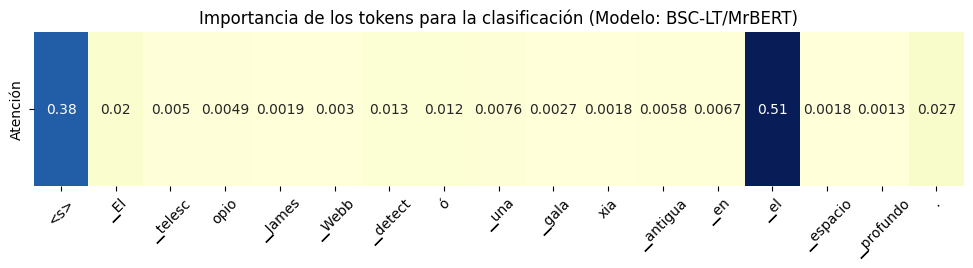

In [102]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_attention(text, model, tokenizer, device="cpu"):
    # 1. Preparar el input y asegurar que el modelo devuelva las atenciones
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # 2. Extraer la atención de la última capa: (batch, heads, seq_len, seq_len)
    # Tomamos la última capa de atención [-1]
    attention = outputs.attentions[-1].to("cpu")

    # 3. Promediar las "cabezas" de atención (heads) para tener una visión global
    # y colapsar al primer token <s> (o [CLS]) que es el que decide la clase
    avg_attention = attention[0].mean(dim=0) # Promedio de todas las heads
    # Convert to float32 before converting to numpy
    cls_attention = avg_attention[0, :].float().numpy() # Atención que el token <s> prestó a los demás

    # 4. Obtener los tokens para las etiquetas del eje
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # 5. Graficar el Mapa de Calor
    plt.figure(figsize=(12, 2))
    sns.heatmap([cls_attention], annot=True, xticklabels=tokens, yticklabels=["Atención"],
                cmap="YlGnBu", cbar=False)
    plt.title(f"Importancia de los tokens para la clasificación (Modelo: {model.config._name_or_path})")
    plt.xticks(rotation=45)
    plt.show()

# --- EJECUCIÓN ---
# Ejemplo con una noticia de astronomía o deportes
frase_prueba = "El telescopio James Webb detectó una galaxia antigua en el espacio profundo."
visualize_attention(frase_prueba, model, tokenizer, device=device)

Bloque de Visualización de Atención (Interpretabilidad)

Generará un mapa de calor donde los colores más oscuros indican los términos que más influyeron en la predicción.

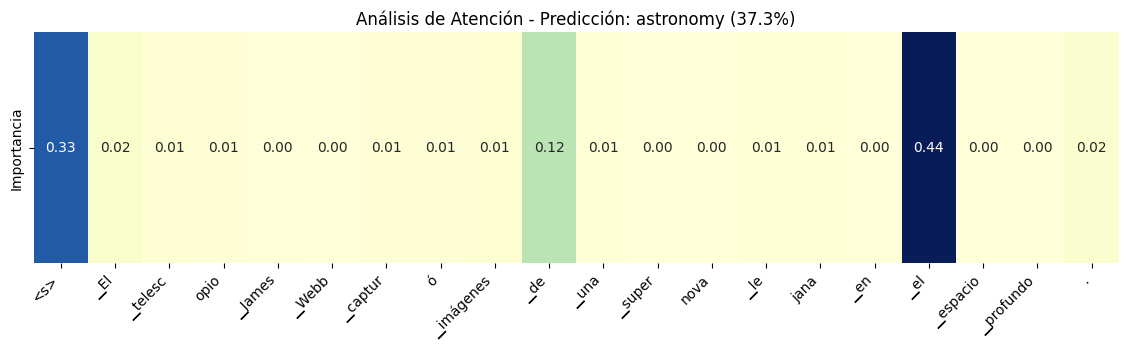

Explicación: El modelo clasificó el texto como 'astronomy' enfocándose principalmente en los tokens con mayores valores.


In [103]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def explain_prediction(text, model, tokenizer, device="cpu"):
    # 1. Tokenización y paso por el modelo
    # Es vital activar output_attentions=True
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        logits = outputs.logits
        attentions = outputs.attentions  # Lista de tensores (uno por capa)

    # 2. Obtener la predicción
    pred_id = torch.argmax(logits, dim=-1).item()
    prob = torch.nn.functional.softmax(logits, dim=-1)[0][pred_id].item()
    label = id2category[pred_id]

    # 3. Procesar Atenciones de la última capa
    # Forma: (batch, num_heads, seq_len, seq_len)
    last_layer_attention = attentions[-1][0]

    # Promediamos las "heads" para tener una visión global de la capa
    # Convert to float32 before converting to numpy
    avg_attention = last_layer_attention.mean(dim=0).cpu().float().numpy()

    # Extraemos la atención que el token <s> (índice 0) prestó a todos los demás tokens
    importance_scores = avg_attention[0, :]

    # 4. Preparar tokens para visualización
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # 5. Graficar el Heatmap
    plt.figure(figsize=(14, 3))
    sns.heatmap([importance_scores], annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=tokens, yticklabels=["Importancia"], cbar=False)

    plt.title(f"Análisis de Atención - Predicción: {label} ({prob*100:.1f}%)")
    plt.xticks(rotation=45, ha='right')
    plt.show()

    print(f"Explicación: El modelo clasificó el texto como '{label}' enfocándose principalmente en los tokens con mayores valores.")

# --- PRUEBA DEL BLOQUE ---
noticia_test = "El telescopio James Webb capturó imágenes de una supernova lejana en el espacio profundo."
explain_prediction(noticia_test, model, tokenizer, device=device)

## Conclusiones